# Customer Attrition
Customer attrition, also known as customer churn, customer turnover, or customer defection, is the loss of clients or customers.

Telephone service companies, Internet service providers, pay TV companies, insurance firms, and alarm monitoring services, often use customer attrition analysis and customer attrition rates as one of their key business metrics because the cost of retaining an existing customer is far less than acquiring a new one. Companies from these sectors often have customer service branches which attempt to win back defecting clients, because recovered long-term customers can be worth much more to a company than newly recruited clients.

Companies usually make a distinction between voluntary churn and involuntary churn. Voluntary churn occurs due to a decision by the customer to switch to another company or service provider, involuntary churn occurs due to circumstances such as a customer's relocation to a long-term care facility, death, or the relocation to a distant location. In most applications, involuntary reasons for churn are excluded from the analytical models. Analysts tend to concentrate on voluntary churn, because it typically occurs due to factors of the company-customer relationship which companies control, such as how billing interactions are handled or how after-sales help is provided.

predictive analytics use churn prediction models that predict customer churn by assessing their propensity of risk to churn. Since these models generate a small prioritized list of potential defectors, they are effective at focusing customer retention marketing programs on the subset of the customer base who are most vulnerable to churn.

* Exploratory Data Analysis
* Data Processing
* Machine Learning

$$ y= w*x+b $$

<b>Gridsearch</b> for paramerter tuning automation

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import classification_report, confusion_matrix

In [3]:
df = pd.read_csv(r"Telco-Customer-Churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## **EDA**

Exploratory Data Analysis

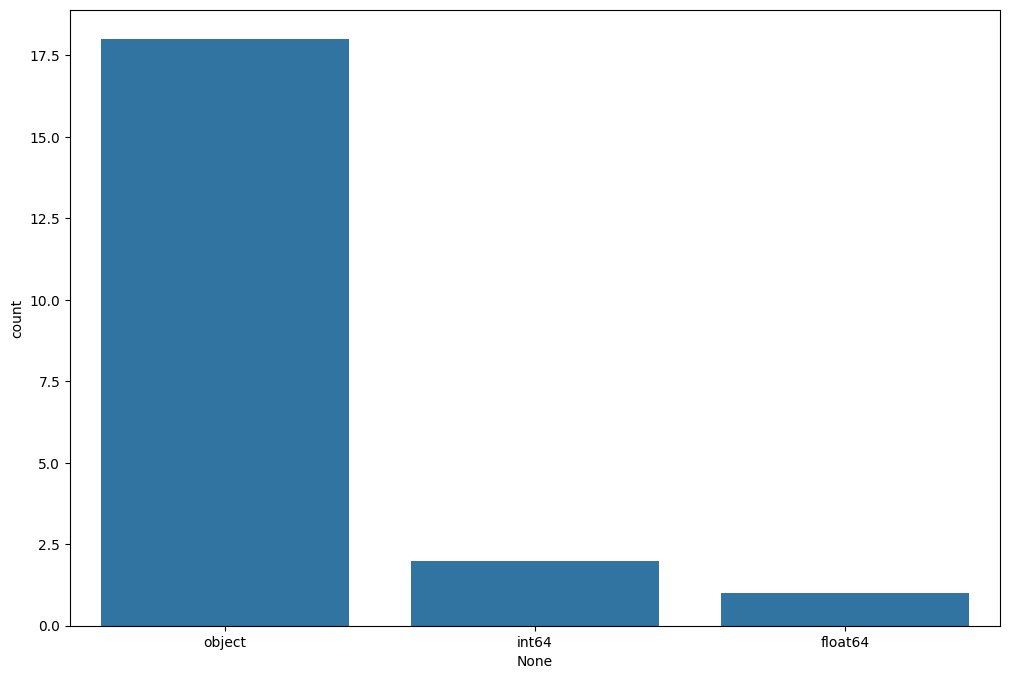

In [6]:
plt.figure(figsize=(12, 8))
sns.countplot(x=df.dtypes.map(str))
plt.show()

Text(0.5, 1.0, 'Customer Churn')

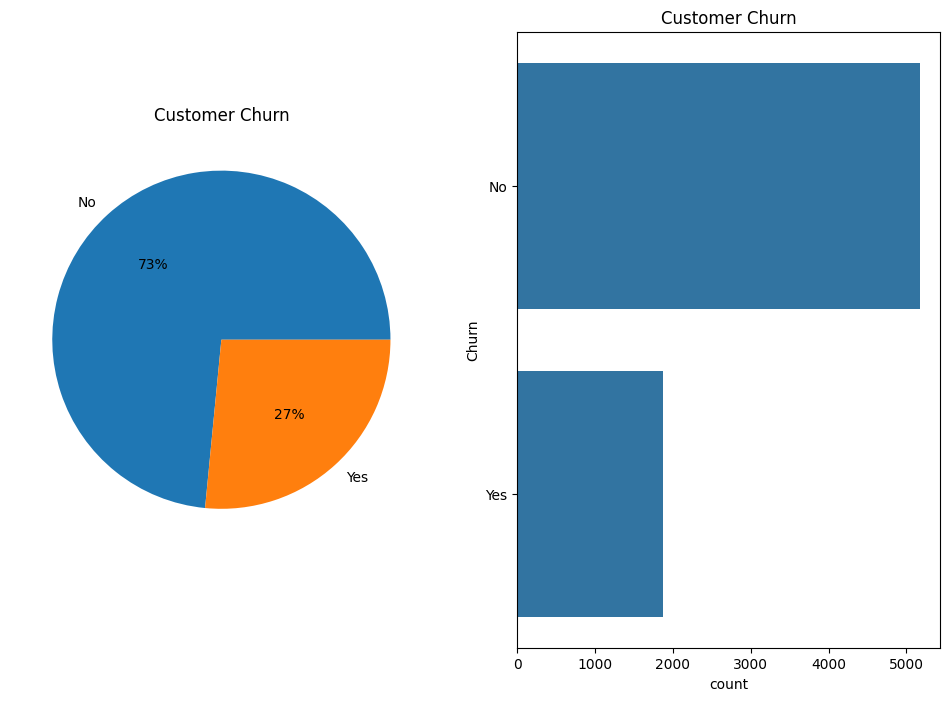

In [7]:
f = plt.figure(figsize=(12 ,8))

ax = f.add_subplot(121)
labels = ['No', 'Yes']
churn = df.Churn.value_counts()
ax.pie(churn, labels=labels, autopct='%.0f%%')
ax.set_title('Customer Churn')

ax = f.add_subplot(122)
sns.countplot(df.Churn)
ax.set_title('Customer Churn')

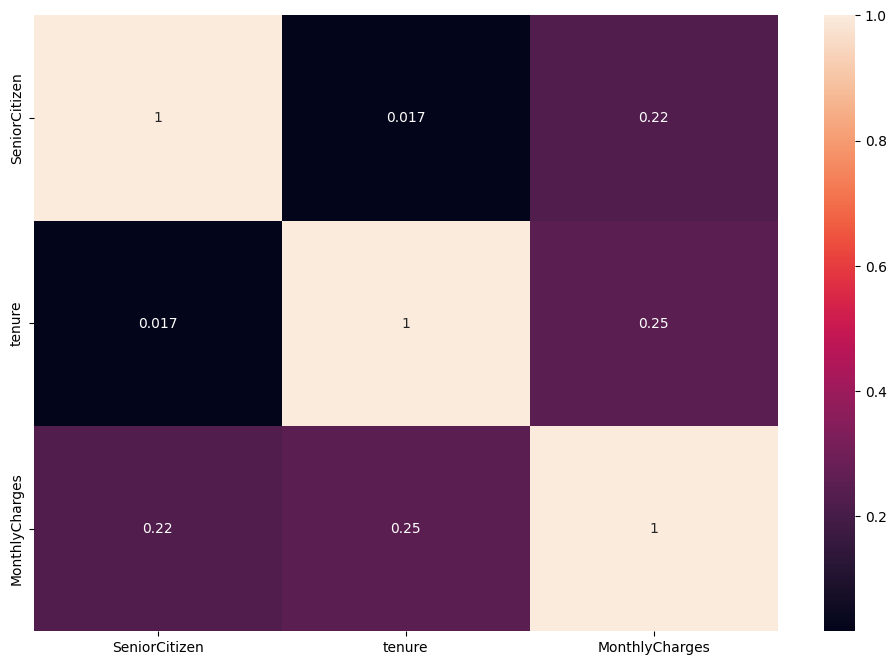

In [8]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True)
plt.show()

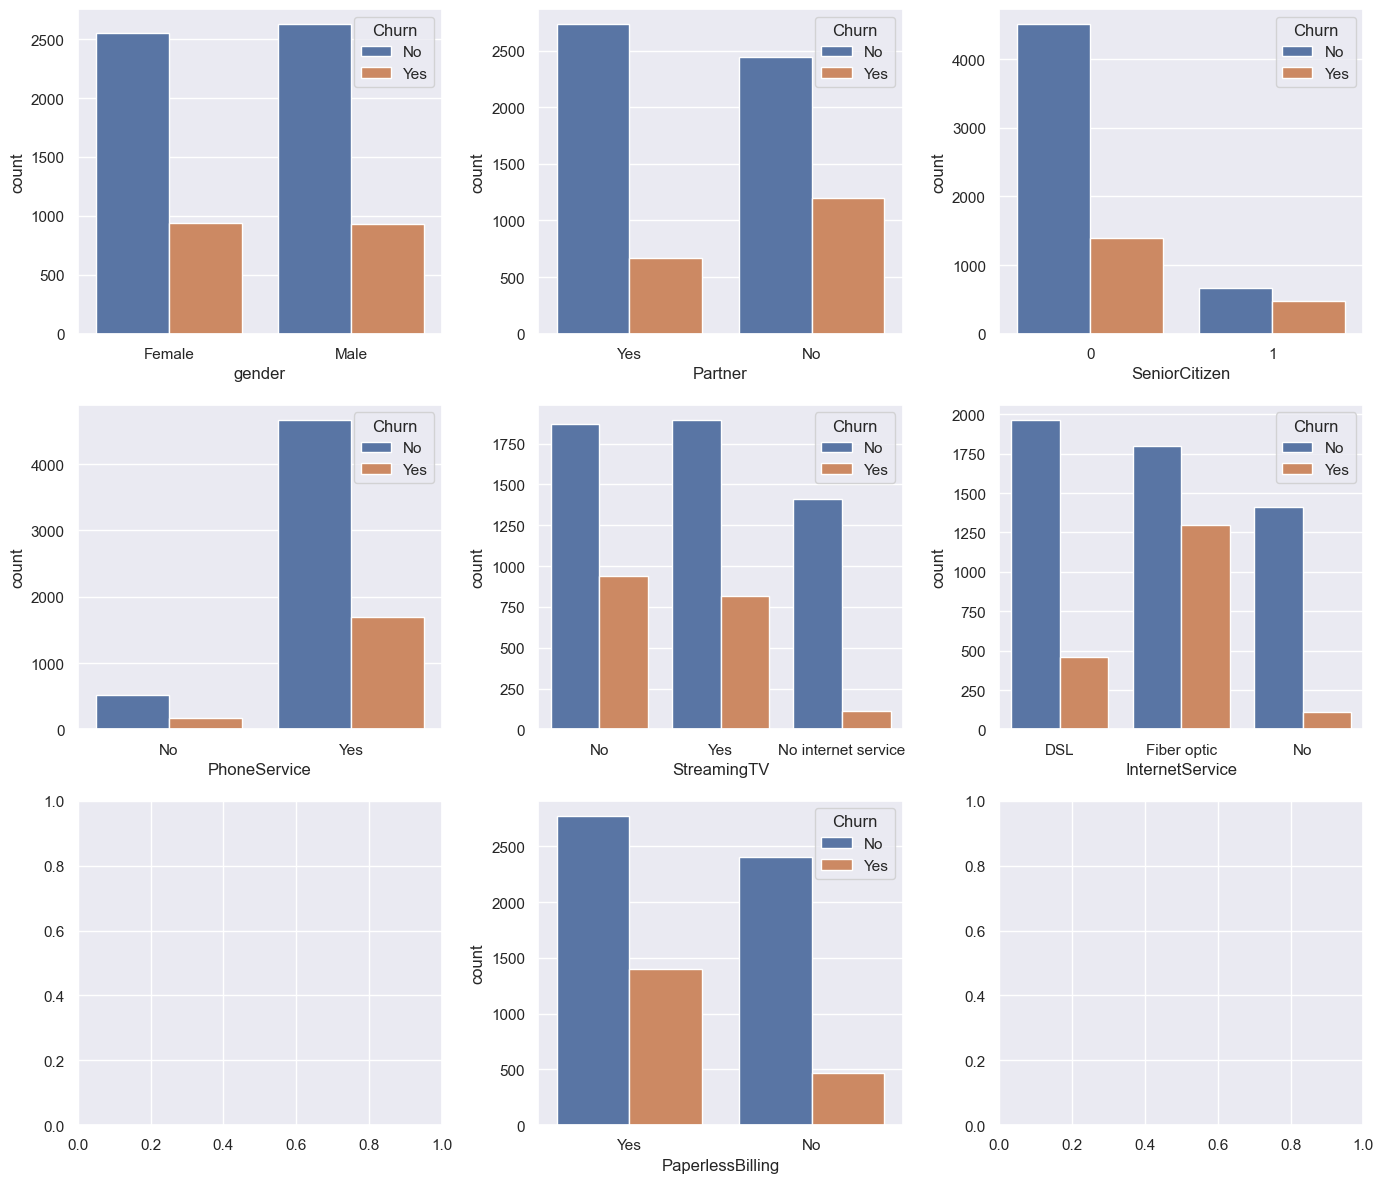

In [9]:
sns.set(style='darkgrid')
# Your code goes here
fig, ax = plt.subplots(3, 3, figsize=(14, 12))
sns.countplot(data=df, x='gender', hue='Churn', ax=ax[0][0])
sns.countplot(data=df, x='Partner', hue='Churn', ax=ax[0][1])
sns.countplot(data=df, x='SeniorCitizen', hue='Churn', ax=ax[0][2])
sns.countplot(data=df, x='PhoneService', hue='Churn', ax=ax[1][0])
sns.countplot(data=df, x='StreamingTV', hue='Churn', ax=ax[1][1])
sns.countplot(data=df, x='InternetService', hue='Churn', ax=ax[1][2])
sns.countplot(data=df, x='PaperlessBilling', hue='Churn', ax=ax[2][1])
plt.tight_layout()
plt.show()

## **Data Preprocessing**

## Data Split
* Split dataset to train and test two test datasets
* Keep original X_test data with categorial data for later after training to consolidating results

In [10]:
X = df.drop('Churn', axis = 1)
y = df['Churn'].map(dict(Yes=1,No=0))

X_train_data, X_test_data, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
# Keep Original X_test_data for later after training to consolidating results

X_train = X_train_data.drop(['customerID'], axis=1)
X_test = X_test_data.drop(['customerID'], axis=1)

In [11]:
#df = df.drop(['customerID'], axis=1)

In [12]:
objList = X_train.select_dtypes(include = "object").columns
le = LabelEncoder()

X_train[objList] = X_train[objList].apply(le.fit_transform)
X_train.describe()

X_test[objList] = X_test[objList].apply(le.fit_transform)
X_test.describe()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
count,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000,1409.000000
mean,0.512420,0.157559,0.477644,0.305891,31.915543,0.912704,0.911994,0.877928,0.783534,0.861604,0.894251,0.782115,0.949610,0.972321,0.689851,0.596167,1.586231,64.088857,686.422995
std,0.500023,0.364456,0.499677,0.460947,24.525829,0.282368,0.951631,0.741909,0.855704,0.871752,0.876315,0.855343,0.881237,0.882243,0.831493,0.490839,1.063927,29.898290,398.539594
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,8.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,35.200000,339.000000
50%,1.000000,0.000000,0.000000,0.000000,28.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,2.000000,69.950000,686.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,89.450000,1032.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,3.000000,116.800000,1376.000000


In [13]:
# use get_dummy - concert catorical data to one hot representation

In [14]:
scale = MinMaxScaler() # (value-min)(Maxmin)
X_train = pd.DataFrame(scale.fit_transform(X_train.values), columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(scale.fit_transform(X_test.values), columns=X_test.columns, index=X_test.index)

In [15]:
X_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
3738,1.0,0.0,0.0,0.0,0.486111,0.0,0.5,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.666667,0.306926,0.181422
3151,1.0,0.0,1.0,1.0,0.208333,1.0,0.0,0.5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.565022,0.045687
4860,1.0,0.0,1.0,1.0,0.180556,0.0,0.5,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.000000,0.220727,0.737251
3867,0.0,0.0,1.0,0.0,0.361111,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.333333,0.549078,0.226730
3810,1.0,0.0,1.0,1.0,0.013889,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.666667,0.260588,0.569100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6303,0.0,0.0,1.0,0.0,0.986111,1.0,1.0,0.5,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.666667,0.905331,0.895545
6227,1.0,0.0,0.0,0.0,0.027778,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.275536,0.919431
4673,0.0,1.0,0.0,0.0,0.347222,1.0,1.0,0.5,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.000000,0.841056,0.347678
2710,0.0,0.0,1.0,0.0,0.333333,1.0,0.0,1.0,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.0,0.333333,0.019930,0.619905


## Machine Learning 
In this section, we will use machine algorithm to predict customer churn

We will test following classification algorithm
* Logistic Regression	
* Gradient Boosting	
* Decision Tree	
* Random Forest	

### Choose machine learning algorithm, training and evaluate model

### Logistic regression

In [16]:
# logistic regression
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
print(log_model.score(X_train, y_train), log_model.score(X_test, y_test))

0.8061767838125665 0.7955997161107168


In [17]:
print(log_model.intercept_)

[-0.78320756]


In [18]:
print(log_model.coef_)

[[ 0.01142677  0.17711261  0.03619485 -0.24803038 -2.33007723 -0.87104949
   0.22394952  0.4688501  -0.55912237 -0.27520303 -0.14665247 -0.51002716
   0.04133125  0.0379202  -1.48895125  0.392581    0.27497994  2.63373386
   0.37446646]]


### GradientBoosting

In [19]:
# Gradient
gradient_model = GradientBoostingClassifier()
gradient_model.fit(X_train, y_train)
print(gradient_model.score(X_train, y_train), gradient_model.score(X_test, y_test))

0.8276535321263756 0.7984386089425124


### Decision Tree

In [20]:
# Decision Tree
tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)
print(tree_model.score(X_train, y_train), tree_model.score(X_test, y_test))

0.9980475683351083 0.7281760113555713


<b> 3 important model concepts </b>

Generalization, Overfiting, underfiting

### Random Forest

In [21]:
# Random Forest
random_model = RandomForestClassifier()
random_model.fit(X_train, y_train)
print(random_model.score(X_train, y_train), random_model.score(X_test, y_test))

0.9980475683351083 0.7885024840312278


### Compare 4 algorithm results togeter

In [22]:
mse = pd.DataFrame(columns=['train', 'test'], index=['Logistic Regression', 'Gradient Boosting', 'Decision Tree',  'Random Forest'])
model_dict = {'Logistic Regression': log_model, 'Gradient Boosting': gradient_model, 'Decision Tree': tree_model, 'Random Forest' : random_model}
  
for name, model in model_dict.items():
    mse.loc[name, 'train'] = model.score(X_train, y_train)*100
    mse.loc[name, 'test'] = model.score(X_test, y_test)*100
 

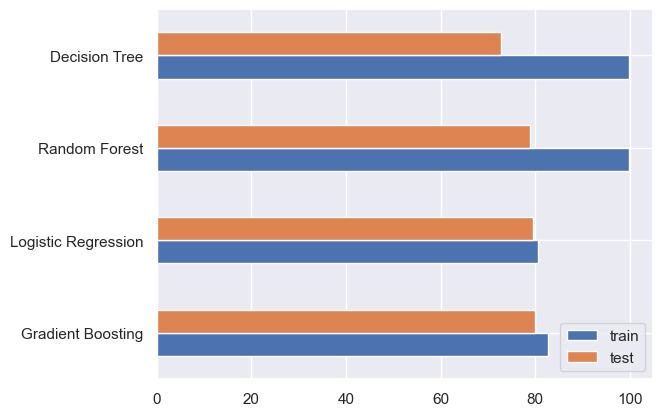

In [23]:
fig, ax = plt.subplots()
mse.sort_values(by='test', ascending=False).plot(kind='barh', ax=ax, zorder=3)
ax.grid(zorder=0)

In [24]:
y_pred = log_model.predict(X_test)
# Print classification report
print('Classification Report Training Model (Logistic Regression) :')
print(classification_report(y_test, y_pred))
pred_proba = log_model.predict_proba(X_test)
print(pred_proba)
print(pred_proba.shape)

Classification Report Training Model (Logistic Regression) :
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.64      0.54      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

[[0.96177424 0.03822576]
 [0.20924133 0.79075867]
 [0.91605393 0.08394607]
 ...
 [0.83343047 0.16656953]
 [0.99422129 0.00577871]
 [0.99266244 0.00733756]]
(1409, 2)


In [25]:
preds=np.array(y_pred)
preds

array([0, 1, 0, ..., 0, 0, 0], shape=(1409,))

In [26]:
X_test_data['Churn'] = preds #pd.Series(preds.reshape(1,-1)[0])

In [27]:
X_test_data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
437,4376-KFVRS,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.2,0
2280,2754-SDJRD,Female,1,No,No,8,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55,1
2235,9917-KWRBE,Female,0,Yes,Yes,41,Yes,Yes,DSL,Yes,...,Yes,No,Yes,No,One year,Yes,Credit card (automatic),78.35,3211.2,0
4460,0365-GXEZS,Male,0,Yes,No,18,Yes,No,Fiber optic,No,...,Yes,Yes,No,No,Month-to-month,No,Electronic check,78.20,1468.75,0
3761,9385-NXKDA,Female,0,Yes,No,72,Yes,Yes,DSL,Yes,...,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),82.65,5919.35,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5143,5204-HMGYF,Female,0,Yes,Yes,49,Yes,No,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,87.20,4345,0
4439,9950-MTGYX,Male,0,Yes,Yes,28,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),20.30,487.95,0
3857,3675-EQOZA,Male,0,No,No,5,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),20.65,93.55,0
4758,3646-ITDGM,Female,0,No,No,56,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.70,1051.9,0


In [28]:
submission = X_test_data[['customerID','Churn']]
submission

,customerID,Churn
437,4376-KFVRS,0
2280,2754-SDJRD,1
2235,9917-KWRBE,0
4460,0365-GXEZS,0
3761,9385-NXKDA,0
...,...,...
5143,5204-HMGYF,0
4439,9950-MTGYX,0
3857,3675-EQOZA,0
4758,3646-ITDGM,0


In [29]:
t= pd.DataFrame(pred_proba,columns = ['No-Churn','Yes-Churn'])
print(t['No-Churn'])
#X_test_data.set_index("customerID")
X_test_data['No-Churn'] = t['No-Churn'].to_numpy()
X_test_data['Yes-Churn'] = t['Yes-Churn'].to_numpy()
X_test_data

0       0.961774
1       0.209241
2       0.916054
3       0.684611
4       0.973998
          ...   
1404    0.946800
1405    0.975984
1406    0.833430
1407    0.994221
1408    0.992662
Name: No-Churn, Length: 1409, dtype: float64


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,No-Churn,Yes-Churn
437,4376-KFVRS,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.2,0,0.961774,0.038226
2280,2754-SDJRD,Female,1,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55,1,0.209241,0.790759
2235,9917-KWRBE,Female,0,Yes,Yes,41,Yes,Yes,DSL,Yes,...,Yes,No,One year,Yes,Credit card (automatic),78.35,3211.2,0,0.916054,0.083946
4460,0365-GXEZS,Male,0,Yes,No,18,Yes,No,Fiber optic,No,...,No,No,Month-to-month,No,Electronic check,78.20,1468.75,0,0.684611,0.315389
3761,9385-NXKDA,Female,0,Yes,No,72,Yes,Yes,DSL,Yes,...,Yes,Yes,Two year,Yes,Credit card (automatic),82.65,5919.35,0,0.973998,0.026002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5143,5204-HMGYF,Female,0,Yes,Yes,49,Yes,No,DSL,Yes,...,Yes,Yes,One year,Yes,Mailed check,87.20,4345,0,0.946800,0.053200
4439,9950-MTGYX,Male,0,Yes,Yes,28,Yes,No,No,No internet service,...,No internet service,No internet service,Two year,Yes,Credit card (automatic),20.30,487.95,0,0.975984,0.024016
3857,3675-EQOZA,Male,0,No,No,5,Yes,No,No,No internet service,...,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),20.65,93.55,0,0.833430,0.166570
4758,3646-ITDGM,Female,0,No,No,56,Yes,No,No,No internet service,...,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.70,1051.9,0,0.994221,0.005779


In [30]:
X_test_data.to_csv(r"Customer_churn_prediction_results.csv")